# Ablation 2: Different Discriminator GAN Experiment

The UNITS in discriminator halfed: 240 -> 120

In [1]:
# allowing project modules
import sys
import os

# Adds the parent directory to the python path
sys.path.append(os.path.abspath('../..'))

import torch
from torch.optim import SGD

# in project imports
from gan.models.preprocessing import train_loader, val_loader, test_loader
from gan.models.config import NUM_PIECES, LEARN_RATE, NUM_EPOCHS, LATENT_D
from gan.models.discriminator import Discriminator
from gan.models.generator import Generator
from gan.models.train import fit
from gan.models.evaluate import evaluate


## Ensuring Reproducibility

In [2]:
# global random seed for all experiments to ensure reproducibility
seed = 42
torch.manual_seed(seed)
g = torch.Generator()
g.manual_seed(seed)

## Preprocessing Data

In [3]:
import torch
import torchvision
from torchvision.transforms import v2
from torchvision.datasets import MNIST
from torch.utils.data.dataloader import DataLoader
from torch.utils.data import random_split

# in-project imports
from gan.models.config import DATA_FLODER_PATH, VAL_SET_LENGTH, NUM_WORKERS, BATCH_SIZE

# load dataset
transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])

train_dataset = MNIST(root=DATA_FLODER_PATH, train=True, download=True, transform=transform)
test_dataset = MNIST(root=DATA_FLODER_PATH, train=False, download=True, transform=transform)

# create dataloaders
train_length = len(train_dataset) - VAL_SET_LENGTH
train_ds, val_ds = random_split(train_dataset, [train_length, VAL_SET_LENGTH], generator=g)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, generator=g)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, generator=g)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

### Calculating the fixed bias for the output layer for generator

In [4]:
train_images, *_ = train_dataset.data.float()

images = train_dataset.data.float().reshape(-1, 784)

pixel_probs = images.mean(dim=0)

eps = 1e-7
pixel_probs = pixel_probs.clamp(eps, 1 - eps)

output_bias = torch.log(
    pixel_probs / (1 - pixel_probs)
)

print(output_bias.shape)

output_bias

torch.Size([784])


tensor([-16.1181, -16.1181, -16.1181, -16.1181, -16.1181, -16.1181, -16.1181,
        -16.1181, -16.1181, -16.1181, -16.1181, -16.1181,  -6.1637,  -4.8415,
         -5.6232,  -8.8047, -16.1181, -16.1181, -16.1181, -16.1181, -16.1181,
        -16.1181, -16.1181, -16.1181, -16.1181, -16.1181, -16.1181, -16.1181,
        -16.1181, -16.1181, -16.1181, -16.1181,  -8.2292,  -6.9938,  -4.6702,
         -3.6934,  -3.0853,  -2.6811,  -1.9912,  -1.6528,  -1.5563,  -1.5338,
         -1.4545,  -1.5565,  -1.4701,  -1.7063,  -2.1959,  -2.5679,  -2.8669,
         -3.8243,  -4.5867,  -5.6420, -16.1181, -16.1181, -16.1181, -16.1181,
        -16.1181, -16.1181,  -6.8421,  -7.2637,  -4.9620,  -5.2005,  -3.0072,
         -1.8286,  -1.0243,   0.0265,   1.8730,  15.9424,  15.9424,  15.9424,
         15.9424,  15.9424,  15.9424,  15.9424,  15.9424,  15.9424,  15.9424,
          0.5470,  -0.8656,  -2.2659,  -3.3104,  -4.7435, -16.1181, -16.1181,
        -16.1181, -16.1181,  -5.7310,  -5.1354,  -4.4094,  -2.59

## Training Setup

In [5]:
# setup trainning
D_model = Discriminator(num_pieces=NUM_PIECES)
G_model = Generator(output_bias)

D_optimizer = SGD(D_model.parameters(), lr=LEARN_RATE)
G_optimizer = SGD(G_model.parameters(), lr=LEARN_RATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
G_model = G_model.to(device)
D_model = D_model.to(device)

# time of training
def recorded_time(elapsed_time):
    minutes = int(elapsed_time // 60)
    seconds = round((elapsed_time / 60 - minutes) * 60)
    print(f"time: {minutes}m {seconds}s")

## Training

Epoch 1/22:
	Discriminator Train   Loss: 0.0062
	Generator Train       Loss: 9.7066
	Discriminator Val     Loss: 0.0001
	Generator Val         Loss: 10.7786
	D Learning Rate:   0.09999960
	G Learning Rate:   0.09999960
	D Momentum:        0.5000
	G Momentum:        0.5000


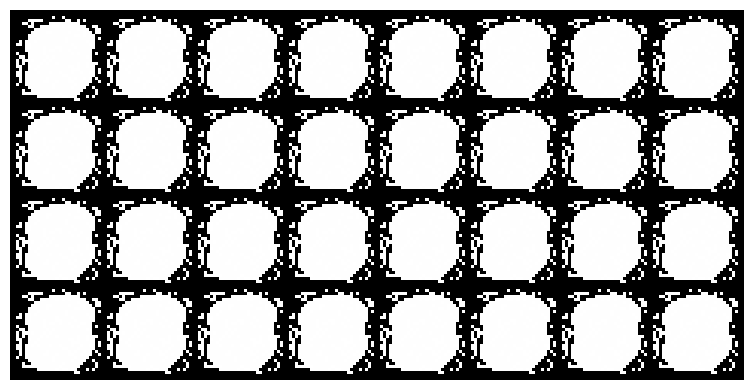

Epoch 2/22:
	Discriminator Train   Loss: 0.0001
	Generator Train       Loss: 11.5214
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 12.2959
	D Learning Rate:   0.09999920
	G Learning Rate:   0.09999920
	D Momentum:        0.5008
	G Momentum:        0.5008
Epoch 3/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 12.6155
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 12.8892
	D Learning Rate:   0.09999880
	G Learning Rate:   0.09999880
	D Momentum:        0.5016
	G Momentum:        0.5016
Epoch 4/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 13.1200
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 13.3850
	D Learning Rate:   0.09999840
	G Learning Rate:   0.09999840
	D Momentum:        0.5024
	G Momentum:        0.5024
Epoch 5/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 13.4651
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 13.6023
	D Learning Rate:   

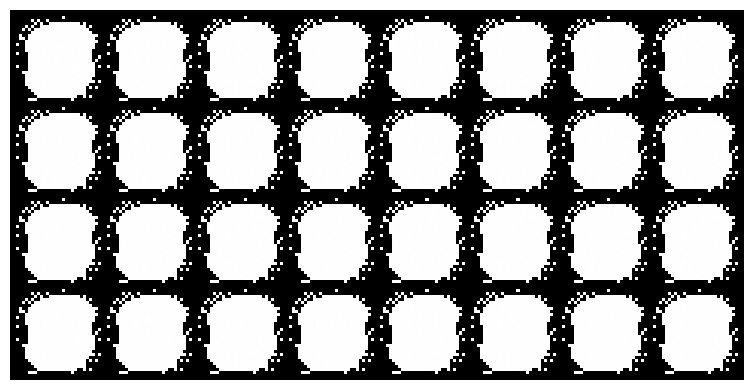

Epoch 6/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 13.6387
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 13.8553
	D Learning Rate:   0.09999760
	G Learning Rate:   0.09999760
	D Momentum:        0.5040
	G Momentum:        0.5040
Epoch 7/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 13.9691
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 14.0964
	D Learning Rate:   0.09999720
	G Learning Rate:   0.09999720
	D Momentum:        0.5048
	G Momentum:        0.5048
Epoch 8/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 14.0688
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 13.7958
	D Learning Rate:   0.09999680
	G Learning Rate:   0.09999680
	D Momentum:        0.5056
	G Momentum:        0.5056
Epoch 9/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 13.8862
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 14.2147
	D Learning Rate:   

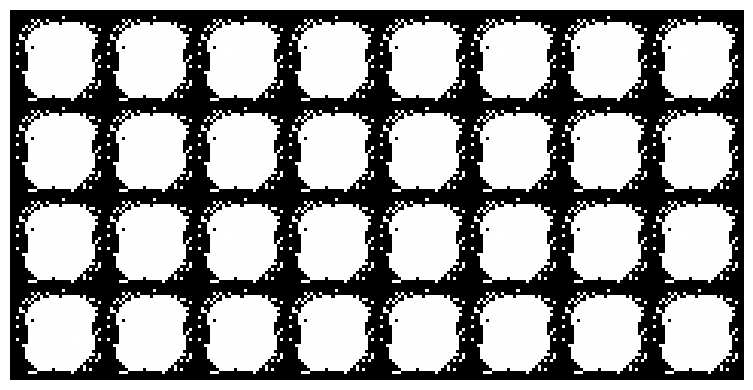

Epoch 11/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 13.9382
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 13.4565
	D Learning Rate:   0.09999560
	G Learning Rate:   0.09999560
	D Momentum:        0.5080
	G Momentum:        0.5080
Epoch 12/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 13.5851
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 13.3986
	D Learning Rate:   0.09999520
	G Learning Rate:   0.09999520
	D Momentum:        0.5088
	G Momentum:        0.5088
Epoch 13/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 12.3316
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 11.7683
	D Learning Rate:   0.09999480
	G Learning Rate:   0.09999480
	D Momentum:        0.5096
	G Momentum:        0.5096
Epoch 14/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 11.6304
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 11.7192
	D Learning Rate

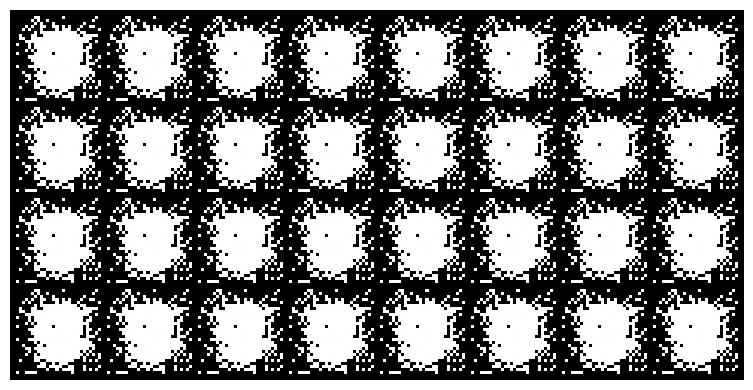

Epoch 16/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 11.4371
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 12.0140
	D Learning Rate:   0.09999360
	G Learning Rate:   0.09999360
	D Momentum:        0.5120
	G Momentum:        0.5120
Epoch 17/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 11.7662
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 12.0874
	D Learning Rate:   0.09999320
	G Learning Rate:   0.09999320
	D Momentum:        0.5129
	G Momentum:        0.5129
Epoch 18/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 12.3769
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 12.3344
	D Learning Rate:   0.09999280
	G Learning Rate:   0.09999280
	D Momentum:        0.5137
	G Momentum:        0.5137
Epoch 19/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 12.7125
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 13.0618
	D Learning Rate

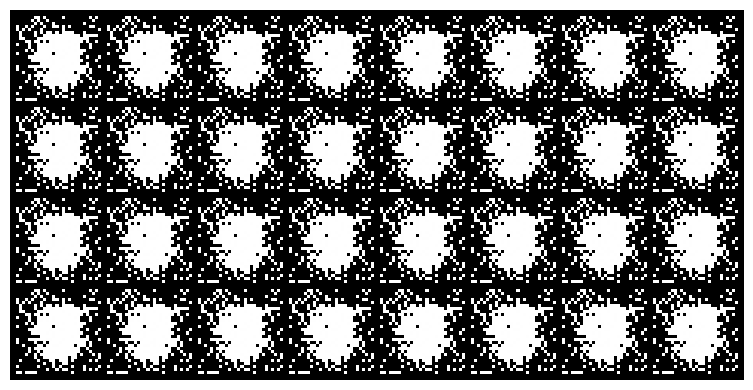

Epoch 21/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 13.5651
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 13.7096
	D Learning Rate:   0.09999160
	G Learning Rate:   0.09999160
	D Momentum:        0.5161
	G Momentum:        0.5161
Epoch 22/22:
	Discriminator Train   Loss: 0.0000
	Generator Train       Loss: 13.6391
	Discriminator Val     Loss: 0.0000
	Generator Val         Loss: 13.5184
	D Learning Rate:   0.09999120
	G Learning Rate:   0.09999120
	D Momentum:        0.5169
	G Momentum:        0.5169


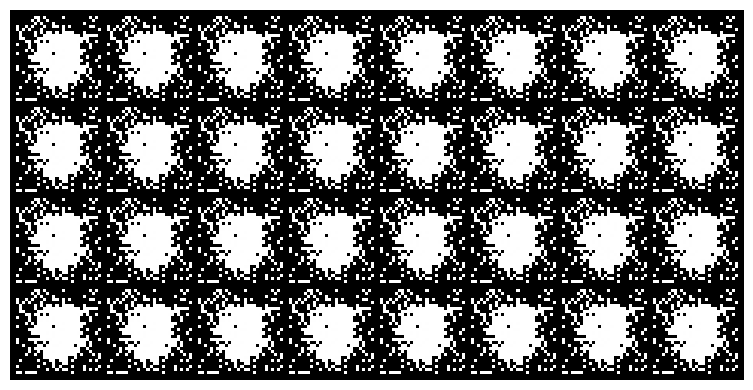

time: 37m 2s


In [6]:
from time import time
start_time = time() # start the timer

# training
history = fit(
    G_model=G_model,
    D_model=D_model,
    epochs=NUM_EPOCHS,
    train_loader=train_loader,
    val_loader=val_loader,
    latent_d=LATENT_D,
    optimizer_D=D_optimizer,
    optimizer_G=G_optimizer,
    loss_generator=G_model.saturated_loss,
    loss_discriminator=D_model.loss,
    device=device
)


elapsed = time() - start_time    
recorded_time(elapsed)

In [7]:
print(history)

{'D': {'train': [0.006244992417150052, 8.025613536707927e-05, 3.1525990118763664e-05, 1.8888811860735367e-05, 1.3497023545837433e-05, 1.0666888360200617e-05, 8.590164056218254e-06, 7.284662660080595e-06, 6.8354968342825534e-06, 5.983774838637888e-06, 5.741626552871536e-06, 6.163820683501243e-06, 1.2220523508892645e-05, 3.414283690590432e-05, 4.8079957595200134e-05, 4.797895443559087e-05, 3.4085505867830857e-05, 1.9707481394304423e-05, 1.3785846065424945e-05, 9.75135368156496e-06, 7.057929688377656e-06, 5.792401213115499e-06], 'val': [0.00013946978128515184, 4.145011513901409e-05, 2.177007179998327e-05, 1.4604988979408517e-05, 1.1151389321457827e-05, 9.032268722512527e-06, 7.501018340917653e-06, 6.810382291223504e-06, 5.979140451381682e-06, 5.3827357332920655e-06, 6.038817238004413e-06, 6.281807674531592e-06, 1.9264955093967727e-05, 3.7434029042196925e-05, 3.5685807644040325e-05, 3.038291854027193e-05, 2.447445349098416e-05, 1.6688241829979233e-05, 1.1149957057205028e-05, 8.157836377358

# Test 

In [8]:
# test
test_result = evaluate(
    D_model=D_model,
    G_model=G_model,
    data_loader=test_loader,
    loss_D_fn=D_model.loss,
    loss_G_fn=G_model.loss,
    latent_d=LATENT_D,
    device=device
)

In [9]:
D_test_loss, G_test_loss = test_result
print("Test Results")
print("\tDiscriminator: ", D_test_loss)
print("\tGenerator:     ", G_test_loss)

Test Results
	Discriminator:  5.794414085903554e-06
	Generator:      -1.3709077393286861e-06


## Results

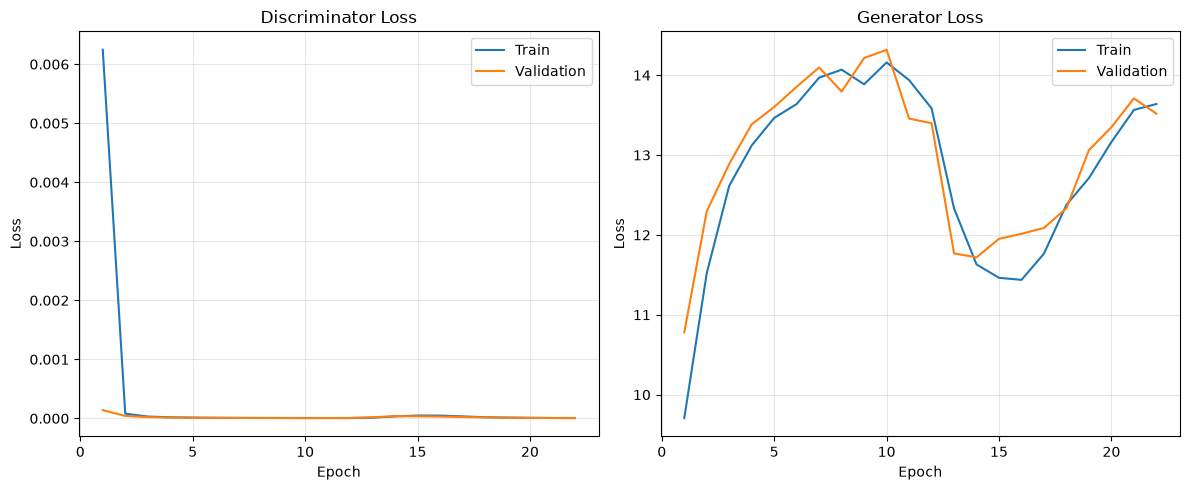

In [10]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["D"]["train"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Discriminator
axes[0].plot(epochs, history["D"]["train"], label="Train")
axes[0].plot(epochs, history["D"]["val"], label="Validation")

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Discriminator Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Generator
axes[1].plot(epochs, history["G"]["train"], label="Train")
axes[1].plot(epochs, history["G"]["val"], label="Validation")

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Generator Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()